# 01 — 2022 Ground Effect Era Baseline

Establishes the competitive baseline for the 2022–2025 Ground Effect Era across four metrics:

1. **Constructor points spread** — Gini coefficient and P1–P10 gap by season
2. **Lap time field spread** — P1–P10 fastest lap gap per race, averaged by season
3. **Reliability** — DNF rates by constructor and year
4. **Qualifying conversion** — how consistently teams/drivers convert grid position to race result

These metrics form the comparison baseline for the 2026 era analysis in notebook 02.

> **Note on data loading:** FastF1 loads each session individually. The first run across all four seasons (2022–2025) will take several minutes as the cache populates. Subsequent runs are fast. Run cells in order.

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from src.data.fastf1_loader import load_session, get_event_schedule
from src.utils.era_helper import get_year_within_era
from src.analysis.points_spread import points_gini_by_round, season_end_gini, points_gap_by_round
from src.analysis.reliability import dnf_rate_by_constructor_year, dnf_causes
from src.analysis.lap_time_delta import fastest_lap_per_driver, p1_to_pn_gap, lap_time_delta_summary, mean_gap_by_season
from src.analysis.quali_race_delta import quali_race_delta, mean_delta_by_constructor

sns.set_theme(style='whitegrid', palette='muted')
GROUND_EFFECT_SEASONS = [2022, 2023, 2024, 2025]
print('Libraries loaded.')

Libraries loaded.


## Load Race Results (2022–2025)

Iterates every race session across the era and builds a flat results DataFrame.
This is the main data loading cell — expect it to take a few minutes on first run.

In [2]:
all_results = []
all_laps = {}  # (season, round) -> laps DataFrame

for season in GROUND_EFFECT_SEASONS:
    schedule = get_event_schedule(season)
    races = schedule[schedule['EventFormat'].isin(['conventional', 'sprint'])]

    for _, event in races.iterrows():
        round_num = int(event['RoundNumber'])
        event_name = event['EventName']

        try:
            session = load_session(season, round_num, 'R')
            results = session.results
            laps = session.laps

            for _, driver in results.iterrows():
                finish_pos = driver.get('Position')
                grid_pos = driver.get('GridPosition')
                pts = driver.get('Points')
                all_results.append({
                    'season': season,
                    'round': round_num,
                    'race_name': event_name,
                    'driver_id': driver.get('Abbreviation', ''),
                    'driver_name': f"{driver.get('FirstName', '')} {driver.get('LastName', '')}".strip(),
                    'constructor_id': str(driver.get('TeamId', '')).lower().replace(' ', '_'),
                    'constructor_name': driver.get('TeamName', ''),
                    'grid_position': int(grid_pos) if pd.notna(grid_pos) else 0,
                    'finish_position': int(finish_pos) if pd.notna(finish_pos) else None,
                    'points': float(pts) if pd.notna(pts) else 0.0,
                    'status': driver.get('Status', ''),
                })

            all_laps[(season, round_num)] = laps
            print(f'  {season} R{round_num:02d} {event_name} — {len(results)} drivers loaded')

        except Exception as e:
            print(f'  {season} R{round_num:02d} {event_name} — SKIPPED ({e})')

results_df = pd.DataFrame(all_results)
print(f'\nTotal race entries loaded: {len(results_df)}')
print(f'Seasons: {sorted(results_df["season"].unique())}')
print(f'Races:   {results_df[["season","round"]].drop_duplicates().shape[0]}')

core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Driver 16 completed the race distance 00:00.050000 before the recorded end of the session.
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['16', '55', '44', '63', '20', '77', '31', '22', '14', '24', '47', 

  2022 R01 Bahrain Grand Prix — 20 drivers loaded


core        WARNING 	No lap data for driver 22
core        WARNING 	No lap data for driver 47
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 22)
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 47)
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '16', '55', '11', '63', '31', '4', '10', '20', '44', '24', '27', '18', '23', '77', '14', '3', '6', '22', '47']
core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap

  2022 R02 Saudi Arabian Grand Prix — 20 drivers loaded


core        WARNING 	Driver 16 completed the race distance 00:00.140000 before the recorded end of the session.
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['16', '11', '63', '44', '4', '3', '31', '77', '10', '23', '24', '18', '47', '20', '22', '6', '14', '1', '5', '55']
core           INFO 	Loading data for Emilia Romagna Grand Prix - Race [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_

...

  2025 R20 Mexico City Grand Prix — 20 drivers loaded


core           INFO 	Loading data for Las Vegas Grand Prix - Race [v3.8.2]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No 

  2025 R22 Las Vegas Grand Prix — 20 drivers loaded


req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INFO 	Data has been written to cache!

  2025 R24 Abu Dhabi Grand Prix — 20 drivers loaded

Total race entries loaded: 1478
Seasons: [np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Races:   74


## 1. Constructor Points Spread

**Gini coefficient** measures how unevenly points are distributed across constructors.
- 0 = all constructors have equal points (maximum parity)
- 1 = one constructor has all the points (minimum parity)

A falling Gini across era years indicates field convergence.

In [3]:
# Build cumulative constructor standings by round
standings_rows = []
for season in GROUND_EFFECT_SEASONS:
    season_df = results_df[results_df['season'] == season].copy()
    season_df = season_df.sort_values('round')
    cumulative = season_df.groupby(['constructor_id', 'round'])['points'].sum().groupby('constructor_id').cumsum().reset_index()
    cumulative['season'] = season
    cumulative.columns = ['constructor_id', 'round', 'points', 'season']
    standings_rows.append(cumulative)

standings_df = pd.concat(standings_rows, ignore_index=True)
standings_df.head()

,constructor_id,round,points,season
0,alfa,1,9.0,2022
1,alfa,2,9.0,2022
2,alfa,3,13.0,2022
3,alfa,4,23.0,2022
4,alfa,5,29.0,2022


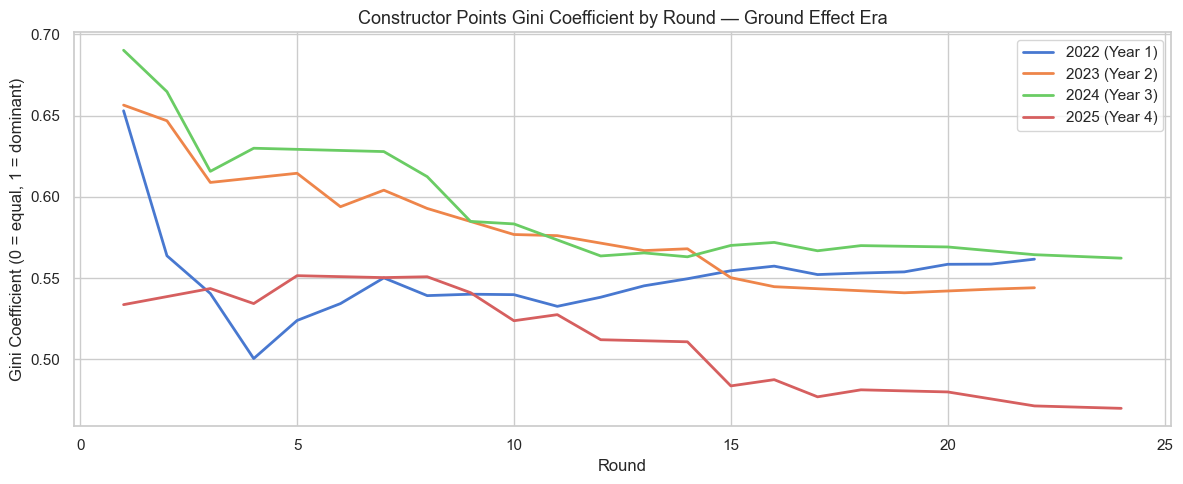


End-of-season Gini by year:
 season  final_round   gini
   2022           22 0.5616
   2023           22 0.5440
   2024           24 0.5623
   2025           24 0.4699


In [4]:
gini_df = points_gini_by_round(standings_df)
gini_df['era_year'] = gini_df['season'].apply(get_year_within_era)

fig, ax = plt.subplots(figsize=(12, 5))
for season in GROUND_EFFECT_SEASONS:
    season_gini = gini_df[gini_df['season'] == season]
    ax.plot(season_gini['round'], season_gini['gini'],
            label=f'{season} (Year {get_year_within_era(season)})', linewidth=2)

ax.set_title('Constructor Points Gini Coefficient by Round — Ground Effect Era', fontsize=13)
ax.set_xlabel('Round')
ax.set_ylabel('Gini Coefficient (0 = equal, 1 = dominant)')
ax.legend()
plt.tight_layout()
plt.show()

print('\nEnd-of-season Gini by year:')
print(season_end_gini(standings_df).to_string(index=False))

## 2. Lap Time Field Spread

The **P1–P10 gap** is the difference in seconds between the fastest and 10th-fastest driver's best lap in each race.
A shrinking gap over era years indicates the field is converging on pace.

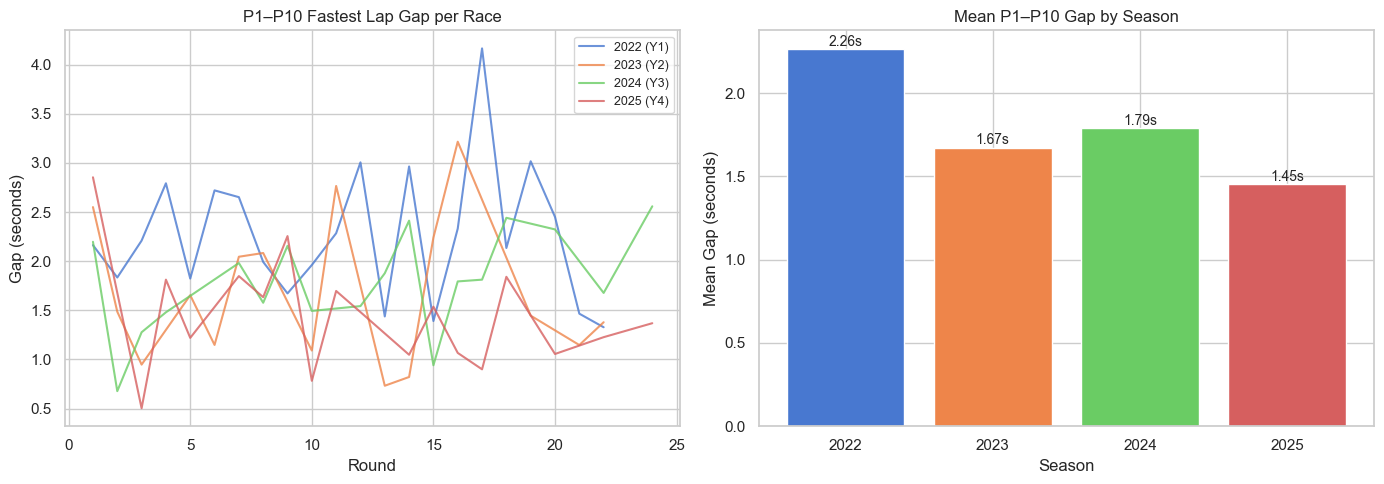


Mean P1–P10 gap by season:
 season  era_year  mean_gap_s  races
   2022         1       2.263     22
   2023         2       1.672     16
   2024         3       1.790     18
   2025         4       1.452     18


In [5]:
delta_df = lap_time_delta_summary(all_laps)
delta_df['era_year'] = delta_df['season'].apply(get_year_within_era)

mean_df = mean_gap_by_season(delta_df)
mean_df['era_year'] = mean_df['season'].apply(get_year_within_era)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Per-race gaps
for season in GROUND_EFFECT_SEASONS:
    s = delta_df[delta_df['season'] == season]
    axes[0].plot(s['round'], s['gap_s'],
                 label=f'{season} (Y{get_year_within_era(season)})', linewidth=1.5, alpha=0.8)
axes[0].set_title('P1–P10 Fastest Lap Gap per Race', fontsize=12)
axes[0].set_xlabel('Round')
axes[0].set_ylabel('Gap (seconds)')
axes[0].legend(fontsize=9)

# Season mean
axes[1].bar(mean_df['season'].astype(str), mean_df['mean_gap_s'], color=sns.color_palette('muted', len(mean_df)))
axes[1].set_title('Mean P1–P10 Gap by Season', fontsize=12)
axes[1].set_xlabel('Season')
axes[1].set_ylabel('Mean Gap (seconds)')
for i, row in mean_df.iterrows():
    axes[1].text(i, row['mean_gap_s'] + 0.02, f"{row['mean_gap_s']:.2f}s", ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print('\nMean P1–P10 gap by season:')
print(mean_df[['season', 'era_year', 'mean_gap_s', 'races']].to_string(index=False))

## 3. Reliability — DNF Rates

DNF rate = retirements as a percentage of race starts, by constructor and season.

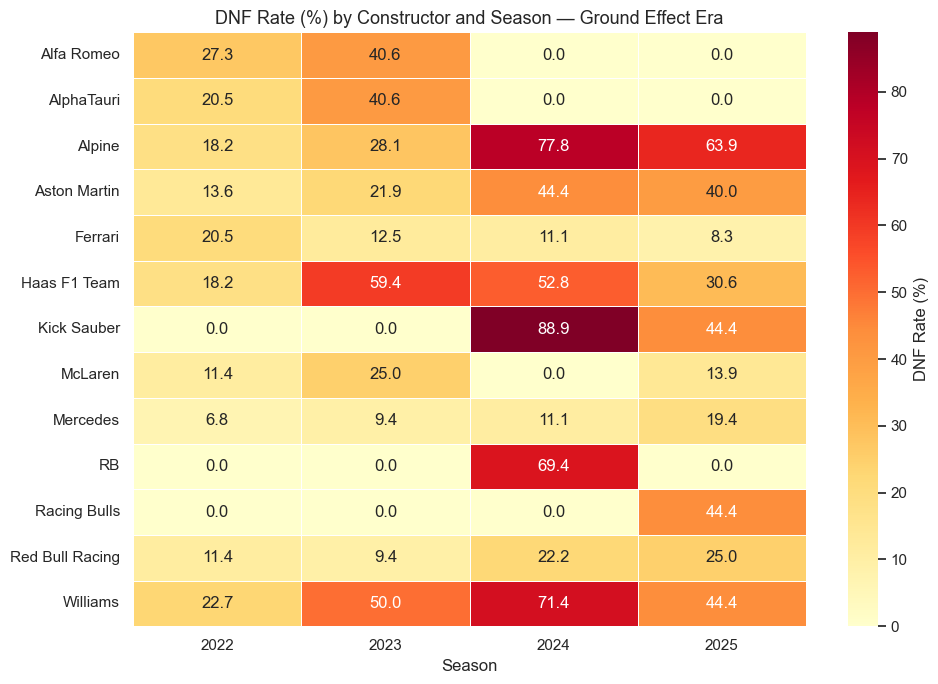


Most common DNF causes:
          status  count
          Lapped    246
         Retired    113
Collision damage     14
        Accident     11
       Collision     10
          Engine      7
      Power Unit      6
   Did not start      5
      Hydraulics      4
    Disqualified      4


In [6]:
dnf_df = dnf_rate_by_constructor_year(results_df)

# Pivot for heatmap — constructors vs seasons
dnf_pivot = dnf_df.pivot_table(
    index='constructor_name', columns='season', values='dnf_rate_pct', fill_value=0
)

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(dnf_pivot, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'DNF Rate (%)'})
ax.set_title('DNF Rate (%) by Constructor and Season — Ground Effect Era', fontsize=13)
ax.set_xlabel('Season')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

print('\nMost common DNF causes:')
print(dnf_causes(results_df).head(10).to_string(index=False))

## 4. Qualifying vs Race Position Conversion

**Position delta** = grid position − finishing position.
- Positive = gained places in the race
- Negative = lost places
- Zero = perfect conversion

DNFs are excluded from averages but counted separately.

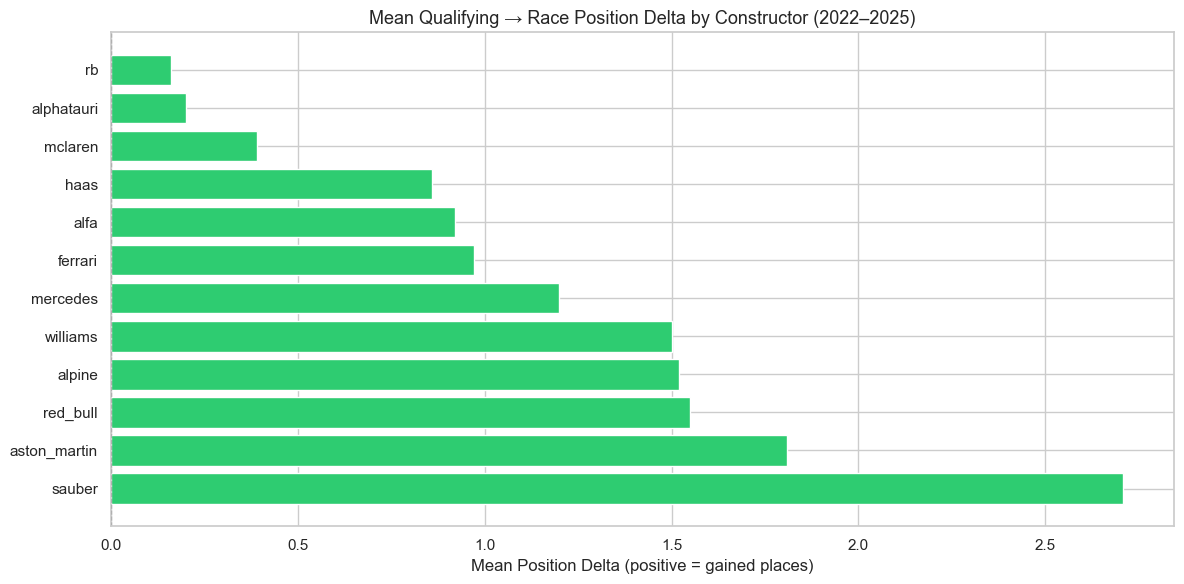


Constructor quali→race conversion (2022–2025):
constructor_id  races  mean_delta  dnf_count
        sauber     24        2.71         48
  aston_martin    104        1.81         43
      red_bull    123        1.55         25
        alpine     80        1.52         68
      williams     80        1.50         67
      mercedes    131        1.20         17
       ferrari    128        0.97         20
          alfa     51        0.92         25
          haas     91        0.86         57
       mclaren    130        0.39         18
    alphatauri     54        0.20         22
            rb     31        0.16         41


In [7]:
delta_results = quali_race_delta(results_df)
constructor_conv = mean_delta_by_constructor(delta_results)

fig, ax = plt.subplots(figsize=(12, 6))
colours = ['#2ecc71' if d >= 0 else '#e74c3c' for d in constructor_conv['mean_delta']]
bars = ax.barh(constructor_conv['constructor_id'], constructor_conv['mean_delta'], color=colours)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Mean Qualifying → Race Position Delta by Constructor (2022–2025)', fontsize=13)
ax.set_xlabel('Mean Position Delta (positive = gained places)')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

print('\nConstructor quali→race conversion (2022–2025):')
print(constructor_conv[['constructor_id', 'races', 'mean_delta', 'dnf_count']].to_string(index=False))

## Baseline Summary

Record key observations here as you run the notebook — these will inform the 2026 comparison.

| Metric | Observation |
|---|---|
| Points Gini | 2022 was an anomaly, however all other years trended downwards (tighter convergence) |
| Lap time convergence | Lap times trended downwards, with an anomaly worth looking into for 2024 |
| Least reliable constructor | 2024 seemed to indicate higher failure rates in most Constructors |
| Best quali→race converter | No real immediate trend analysis without delving further into related dataset comparisons |

**Proceed to `02_2026_era_year1.ipynb` once 2026 data is available (Miami onward).**